# Project 2: Predicting Insurance Claim Amounts

## Introduction
In this project, I used the Medical Cost Personal Dataset to predict insurance charges based on personal information such as age, BMI, smoking status, gender, region, and number of children. The main objective of this project is to train a Linear Regression model and evaluate its performance using MAE and RMSE.

## Importing Libraries
In this step, I imported the required Python libraries. Pandas and NumPy are used for data handling. Matplotlib and Seaborn are used for visualization. Scikit-learn is used for model training and evaluation.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load Medical Cost Personal Dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

# Display first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The first five rows of the dataset are displayed using the head() function. The dataset contains personal information such as age, sex, BMI, children, smoker, region, and charges.

## Dataset Structure
The shape shows the number of rows and columns in the dataset. The columns show the names of all features present in the dataset.

In [3]:
# Check shape of dataset
print("Shape of dataset:", df.shape)

# Check column names
print("Columns:", df.columns)

Shape of dataset: (1338, 7)
Columns: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


The info() function shows the data types of each column and helps us check whether any column contains missing values.

In [4]:
# Basic information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The describe() function gives a statistical summary of numerical columns such as age, BMI, children, and charges. It shows count, mean, standard deviation, minimum, maximum, and quartile values.

In [5]:
# Statistical summary
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Checking Missing Values
This step checks whether the dataset contains any missing or null values. If all values are zero, it means no missing value handling is required.

In [6]:
# Check missing values
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


This step checks duplicate records in the dataset. Duplicate rows can affect model performance, so they should be checked before training the model.

In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(1)

In [9]:
# Remove duplicate rows if present
df = df.drop_duplicates()

## Smoking Status and Insurance Charges
This box plot shows the relationship between smoking status and insurance charges. It helps us compare the charges of smokers and non-smokers.

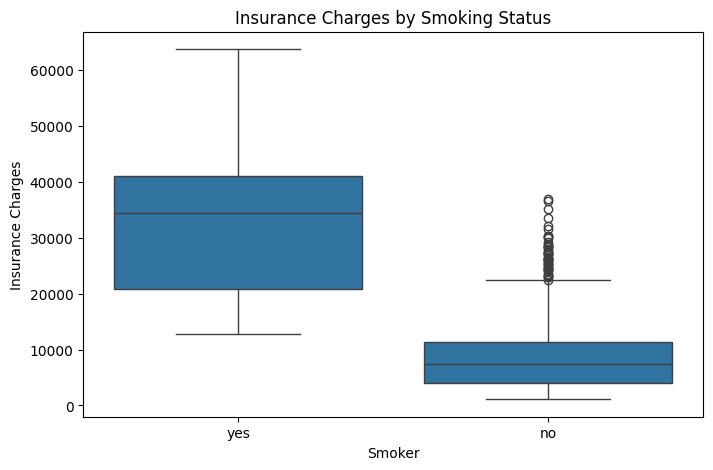

In [10]:
# Box plot: Smoking status vs charges
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Insurance Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")
plt.show()

The graph shows that smokers usually have higher insurance charges compared to non-smokers. This means smoking status has a strong impact on medical insurance cost.

## Age and Insurance Charges
This scatter plot shows the relationship between age and insurance charges. Different colors are used to show smokers and non-smokers.

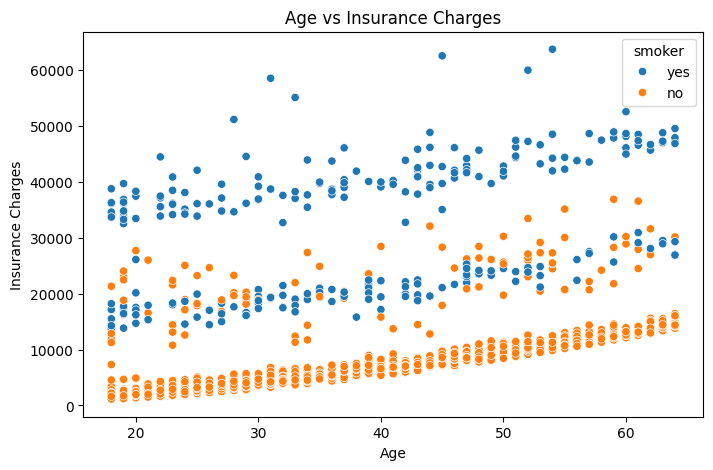

In [11]:
# Scatter plot: Age vs charges
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.show()

The graph shows that insurance charges generally increase with age. Smokers have higher charges even at different age levels.

## BMI and Insurance Charges
This scatter plot shows how BMI affects insurance charges. Smoking status is also shown using different colors.

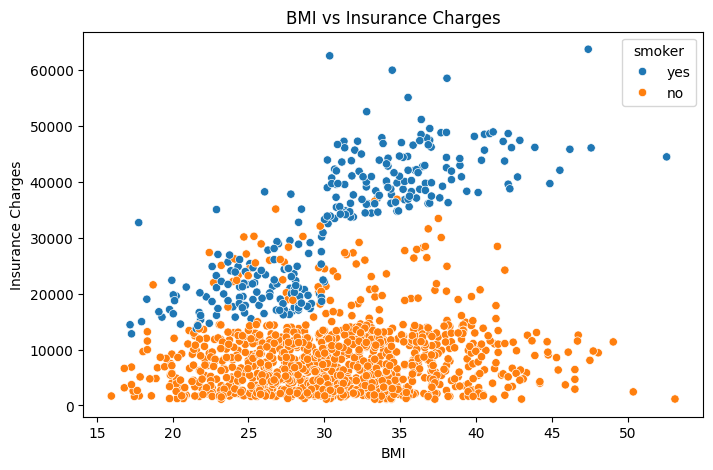

In [12]:
# Scatter plot: BMI vs charges
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.show()

The graph shows that people with higher BMI may have higher insurance charges, especially if they are smokers.

## Encoding Categorical Features
Machine learning models work with numerical values. Therefore, categorical columns such as sex, smoker, and region are converted into numerical columns using one-hot encoding.

In [13]:
# Convert categorical columns into numerical columns
df_encoded = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

# Display first 5 rows after encoding
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## Feature and Target Selection
The target variable is charges because we want to predict insurance charges. All other columns are used as input features for the model.

In [14]:
# Separate features and target variable
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1337, 8)
Target shape: (1337,)


## Splitting the Dataset
The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to check model performance.

In [15]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1069, 8)
Testing data: (268, 8)


## Model Training
A Linear Regression model is trained to predict insurance charges based on the selected features.

In [16]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Model Prediction
The trained model is used to predict insurance charges for the test data.

In [17]:
# Make predictions
y_pred = model.predict(X_test)

# Display first 5 predictions
y_pred[:5]

array([ 8143.69388412,  5737.11568259, 14369.31487618, 31745.51363586,
        8962.38665706])

## Model Evaluation
The model is evaluated using MAE, RMSE, and R2 Score. MAE shows the average prediction error. RMSE shows the error with more penalty for large mistakes. R2 Score shows how well the model explains the variation in insurance charges.

In [18]:
# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 4177.045561036319
Root Mean Squared Error (RMSE): 5956.342894363588
R2 Score: 0.8069287081198011


## Actual vs Predicted Values
This table compares the actual insurance charges with the predicted charges. It helps us understand how close the model predictions are to the real values.

In [19]:
# Compare actual and predicted values
comparison = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": y_pred
})

comparison.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


## Conclusion

In this project, the Medical Cost Personal Dataset was used to predict insurance charges. The dataset was explored using pandas, and visualizations were created to understand the effect of age, BMI, and smoking status on charges. Categorical columns were encoded into numerical form. A Linear Regression model was trained and tested. The model was evaluated using MAE, RMSE, and R2 Score. The analysis showed that smoking status, age, and BMI are important factors that affect insurance charges.